In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")
sample_submission = pd.read_csv("../data/sample_submission.csv")

In [7]:
train.shape, test.shape, sample_submission.shape

((668665, 15), (286571, 14), (286571, 2))

In [8]:
train.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [9]:
test.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level
0,668665,61,67725.0,16.9,2,7,4,4.0,Male,Suburban,Sedan,Yes,No,Low
1,668666,42,152835.0,41.9,2,9,9,4.0,Male,Urban,SUV,No,No,Low
2,668667,68,86877.0,53.3,1,10,11,4.0,Female,Urban,Sedan,No,No,Low
3,668668,39,46794.0,34.1,2,4,8,4.0,Female,Suburban,Sedan,Yes,No,Low
4,668669,55,112172.0,57.2,1,6,4,1.0,Female,Suburban,Sedan,Yes,Yes,Low


In [10]:
sample_submission.head()

,id,Will_Buy_EV
0,668665,0.174645
1,668666,0.174645
2,668667,0.174645
3,668668,0.174645
4,668669,0.174645


In [11]:
train.columns.tolist()

['id',
 'Age',
 'Annual_Income_USD',
 'Daily_Commute_km',
 'Number_of_Cars_Owned',
 'Charging_Stations_Near_Home',
 'Charging_Stations_Near_Work',
 'Environmental_Concern_Level',
 'Gender',
 'City_Type',
 'Current_Car_Type',
 'Home_Charging_Possible',
 'Subsidy_Available',
 'Range_Anxiety_Level',
 'Will_Buy_EV']

In [12]:
set(train.columns) - set(test.columns)

{'Will_Buy_EV'}

In [13]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

## Data Quality Checks

In [14]:
train.isna().sum()

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64

In [15]:
test.isna().sum()

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
dtype: int64

In [16]:
train.duplicated().sum()

np.int64(0)

In [17]:
test.duplicated().sum()

np.int64(0)

In [18]:
train.drop(columns=["id"]).duplicated().sum()

np.int64(0)

In [19]:
test.drop(columns=["id"]).duplicated().sum()

np.int64(0)

In [20]:
train["id"].nunique(), len(train)

(668665, 668665)

In [21]:
test["id"].nunique(), len(test)

(286571, 286571)

In [22]:
train["id"].min(), train["id"].max(), test["id"].min(), test["id"].max()

(np.int64(0), np.int64(668664), np.int64(668665), np.int64(955235))

In [23]:
train.nunique().sort_values()

Subsidy_Available                   2
Will_Buy_EV                         2
Home_Charging_Possible              2
Gender                              3
City_Type                           3
Range_Anxiety_Level                 3
Number_of_Cars_Owned                4
Current_Car_Type                    4
Environmental_Concern_Level         5
Charging_Stations_Near_Home        15
Charging_Stations_Near_Work        20
Age                                45
Daily_Commute_km                  805
Annual_Income_USD               13214
id                             668665
dtype: int64

In [24]:
categorical_cols = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Range_Anxiety_Level",
]

In [25]:
for col in categorical_cols:
    print(f"\n{col}")
    print(train[col].value_counts())


Gender
Gender
Male      367954
Female    295427
Other       5284
Name: count, dtype: int64

City_Type
City_Type
Urban       289305
Suburban    255377
Rural       123983
Name: count, dtype: int64

Current_Car_Type
Current_Car_Type
Sedan        303459
SUV          246545
Hatchback     79438
Truck         39223
Name: count, dtype: int64

Home_Charging_Possible
Home_Charging_Possible
Yes    462677
No     205988
Name: count, dtype: int64

Subsidy_Available
Subsidy_Available
Yes    419909
No     248756
Name: count, dtype: int64

Range_Anxiety_Level
Range_Anxiety_Level
Low       603972
Medium     62499
High        2194
Name: count, dtype: int64


In [26]:
train["Will_Buy_EV"].value_counts()

Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64

In [27]:
train["Will_Buy_EV"].value_counts(normalize=True)

Will_Buy_EV
No     0.825355
Yes    0.174645
Name: proportion, dtype: float64

In [28]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,668665.0,334332.000000,193027.103211,0.0,167166.0,334332.0,501498.0,668664.0
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0


In [29]:
numeric_cols = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level",
]

In [30]:
comparison = pd.DataFrame({
    "train_min": train[numeric_cols].min(),
    "train_max": train[numeric_cols].max(),
    "test_min": test[numeric_cols].min(),
    "test_max": test[numeric_cols].max(),
})

comparison

,train_min,train_max,test_min,test_max
Age,25.0,69.0,25.0,69.0
Annual_Income_USD,30000.0,188549.0,30000.0,186936.0
Daily_Commute_km,5.0,98.7,5.0,103.9
Number_of_Cars_Owned,1.0,4.0,1.0,4.0
Charging_Stations_Near_Home,0.0,14.0,0.0,14.0
Charging_Stations_Near_Work,0.0,19.0,0.0,19.0
Environmental_Concern_Level,1.0,5.0,1.0,5.0


## Train-Test Consistency

In [31]:
for col in categorical_cols:
    train_values = set(train[col].unique())
    test_values = set(test[col].unique())

    print(f"\n{col}")
    print("Train only:", train_values - test_values)
    print("Test only: ", test_values - train_values)


Gender
Train only: set()
Test only:  set()

City_Type
Train only: set()
Test only:  set()

Current_Car_Type
Train only: set()
Test only:  set()

Home_Charging_Possible
Train only: set()
Test only:  set()

Subsidy_Available
Train only: set()
Test only:  set()

Range_Anxiety_Level
Train only: set()
Test only:  set()


In [32]:
target_numeric = train["Will_Buy_EV"].map({
    "No": 0,
    "Yes": 1
})

In [33]:
target_numeric.head()

0    0
1    0
2    1
3    0
4    0
Name: Will_Buy_EV, dtype: int64

In [34]:
target_numeric.mean()

np.float64(0.17464500160768098)

In [35]:
analysis_df = train.copy()

analysis_df["Target"] = target_numeric

In [36]:
for col in categorical_cols:
    rates = (
        analysis_df
        .groupby(col)["Target"]
        .agg(["mean", "count"])
        .sort_values("mean", ascending=False)
    )

    print(f"\n{col}")
    print(rates)


Gender
            mean   count
Gender                  
Female  0.177641  295427
Other   0.173732    5284
Male    0.172253  367954

City_Type
               mean   count
City_Type                  
Rural      0.193389  123983
Suburban   0.180936  255377
Urban      0.161058  289305

Current_Car_Type
                      mean   count
Current_Car_Type                  
SUV               0.180953  246545
Hatchback         0.174299   79438
Sedan             0.171967  303459
Truck             0.156413   39223

Home_Charging_Possible
                            mean   count
Home_Charging_Possible                  
Yes                     0.195819  462677
No                      0.127085  205988

Subsidy_Available
                       mean   count
Subsidy_Available                  
Yes                0.274695  419909
No                 0.005757  248756

Range_Anxiety_Level
                         mean   count
Range_Anxiety_Level                  
Low                  0.189027  603972
Me

In [37]:
analysis_df.groupby("Will_Buy_EV")[numeric_cols].mean().T

Will_Buy_EV,No,Yes
Age,47.083293,46.830654
Annual_Income_USD,81794.588556,98827.302948
Daily_Commute_km,32.553478,30.290714
Number_of_Cars_Owned,1.711319,1.718802
Charging_Stations_Near_Home,4.989947,4.820807
Charging_Stations_Near_Work,7.205490,7.038432
Environmental_Concern_Level,2.630395,4.377268


In [38]:
environment_rates = (
    analysis_df
    .groupby("Environmental_Concern_Level")["Target"]
    .agg(["mean", "count"])
)

environment_rates

,mean,count
Environmental_Concern_Level,,
1.0,0.005655,147476
2.0,0.021379,135133
3.0,0.110922,127351
4.0,0.248848,130469
5.0,0.518287,128236


In [39]:
car_rates = (
    analysis_df
    .groupby("Number_of_Cars_Owned")["Target"]
    .agg(["mean", "count"])
)

car_rates

,mean,count
Number_of_Cars_Owned,,
1,0.171350,288012
2,0.178184,298287
3,0.174848,68877
4,0.165691,13489


In [40]:
analysis_df["Income_Decile"] = pd.qcut(
    analysis_df["Annual_Income_USD"],
    q=10,
    duplicates="drop"
)

In [41]:
income_rates = (
    analysis_df
    .groupby("Income_Decile", observed=True)["Target"]
    .agg(["mean", "count"])
)

income_rates

,mean,count
Income_Decile,,
"(29999.999, 45980.0]",0.044486,66942
"(45980.0, 62671.0]",0.084593,66861
"(62671.0, 71832.0]",0.106622,66834
"(71832.0, 78915.0]",0.131650,66844
"(78915.0, 84880.0]",0.156083,66977
"(84880.0, 91619.0]",0.179741,67013
"(91619.0, 96748.0]",0.197670,66616
"(96748.0, 107798.0]",0.219553,66854
"(107798.0, 122349.0]",0.289040,66970


In [42]:
analysis_df["Commute_Decile"] = pd.qcut(
    analysis_df["Daily_Commute_km"],
    q=10,
    duplicates="drop"
)

In [43]:
commute_rates = (
    analysis_df
    .groupby("Commute_Decile", observed=True)["Target"]
    .agg(["mean", "count"])
)

commute_rates

,mean,count
Commute_Decile,,
"(4.999, 21.9]",0.196327,201796
"(21.9, 28.3]",0.181567,66306
"(28.3, 33.6]",0.168078,66505
"(33.6, 39.0]",0.173410,66680
"(39.0, 44.9]",0.182021,67355
"(44.9, 49.8]",0.158270,66576
"(49.8, 55.8]",0.165747,67205
"(55.8, 98.7]",0.127487,66242


## Feature-Target Relationships

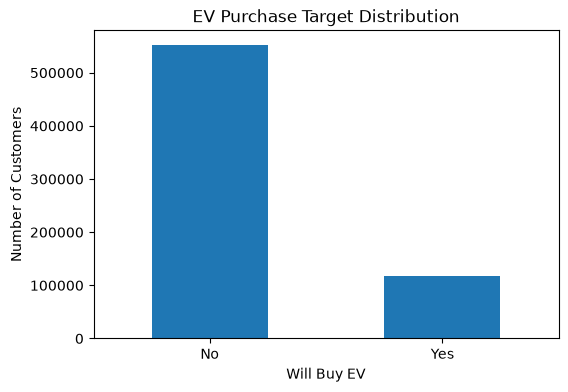

In [44]:
target_counts = train["Will_Buy_EV"].value_counts()

plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")

plt.title("EV Purchase Target Distribution")
plt.xlabel("Will Buy EV")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

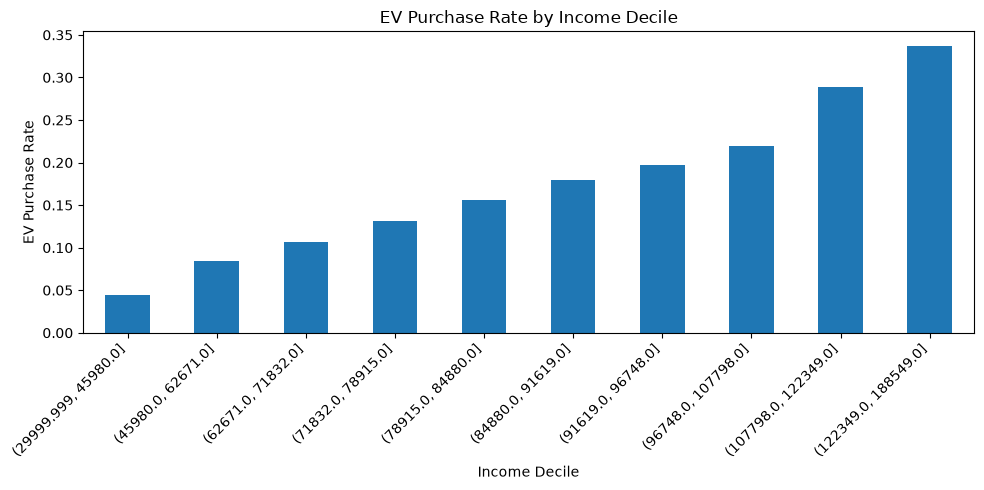

In [45]:
plt.figure(figsize=(10, 5))

income_rates["mean"].plot(kind="bar")

plt.title("EV Purchase Rate by Income Decile")
plt.xlabel("Income Decile")
plt.ylabel("EV Purchase Rate")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

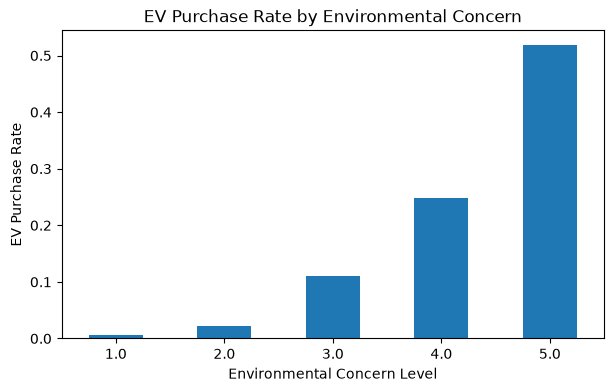

In [46]:
plt.figure(figsize=(7, 4))

environment_rates["mean"].plot(kind="bar")

plt.title("EV Purchase Rate by Environmental Concern")
plt.xlabel("Environmental Concern Level")
plt.ylabel("EV Purchase Rate")
plt.xticks(rotation=0)

plt.show()

In [47]:
category_summary = []

for col in categorical_cols:
    grouped = analysis_df.groupby(col)["Target"].agg(["mean", "count"])

    for category, row in grouped.iterrows():
        category_summary.append({
            "Feature": col,
            "Category": category,
            "Purchase_Rate": row["mean"],
            "Count": int(row["count"])
        })

category_summary = pd.DataFrame(category_summary)

category_summary.sort_values(
    "Purchase_Rate",
    ascending=False
)

,Feature,Category,Purchase_Rate,Count
13,Subsidy_Available,Yes,0.274695,419909
11,Home_Charging_Possible,Yes,0.195819,462677
3,City_Type,Rural,0.193389,123983
15,Range_Anxiety_Level,Low,0.189027,603972
7,Current_Car_Type,SUV,0.180953,246545
4,City_Type,Suburban,0.180936,255377
0,Gender,Female,0.177641,295427
6,Current_Car_Type,Hatchback,0.174299,79438
2,Gender,Other,0.173732,5284
1,Gender,Male,0.172253,367954


In [48]:
analysis_df.groupby("Will_Buy_EV")[numeric_cols].mean().T

Will_Buy_EV,No,Yes
Age,47.083293,46.830654
Annual_Income_USD,81794.588556,98827.302948
Daily_Commute_km,32.553478,30.290714
Number_of_Cars_Owned,1.711319,1.718802
Charging_Stations_Near_Home,4.989947,4.820807
Charging_Stations_Near_Work,7.205490,7.038432
Environmental_Concern_Level,2.630395,4.377268


In [49]:
subsidy_environment = pd.pivot_table(
    analysis_df,
    values="Target",
    index="Environmental_Concern_Level",
    columns="Subsidy_Available",
    aggfunc="mean"
)

subsidy_environment

Subsidy_Available,No,Yes
Environmental_Concern_Level,,
1.0,0.000168,0.009385
2.0,0.000492,0.034780
3.0,0.003029,0.186597
4.0,0.008088,0.399414
5.0,0.024756,0.693279


In [50]:
subsidy_anxiety = pd.pivot_table(
    analysis_df,
    values="Target",
    index="Range_Anxiety_Level",
    columns="Subsidy_Available",
    aggfunc="mean"
)

subsidy_anxiety

Subsidy_Available,No,Yes
Range_Anxiety_Level,,
High,0.000000,0.002295
Low,0.006321,0.295658
Medium,0.000989,0.069433


In [51]:
environment_anxiety = pd.pivot_table(
    analysis_df,
    values="Target",
    index="Environmental_Concern_Level",
    columns="Range_Anxiety_Level",
    aggfunc="mean"
)

environment_anxiety

Range_Anxiety_Level,High,Low,Medium
Environmental_Concern_Level,,,
1.0,0.000000,0.006238,0.001017
2.0,0.000000,0.023523,0.003888
3.0,0.000000,0.120400,0.025229
4.0,0.000000,0.268310,0.059132
5.0,0.013216,0.544886,0.174104


In [52]:
analysis_df["Income_Decile_Number"] = pd.qcut(
    analysis_df["Annual_Income_USD"],
    q=10,
    labels=False
) + 1

In [53]:
income_subsidy = pd.pivot_table(
    analysis_df,
    values="Target",
    index="Income_Decile_Number",
    columns="Subsidy_Available",
    aggfunc="mean"
)

income_subsidy

Subsidy_Available,No,Yes
Income_Decile_Number,,
1,0.001262,0.070829
2,0.002168,0.142795
3,0.003859,0.176056
4,0.004509,0.214605
5,0.004456,0.249795
6,0.005936,0.286085
7,0.006953,0.309283
8,0.006186,0.337232
9,0.011212,0.422789


In [54]:
train_test_numeric = pd.DataFrame({
    "train_mean": train[numeric_cols].mean(),
    "test_mean": test[numeric_cols].mean(),
    "train_std": train[numeric_cols].std(),
    "test_std": test[numeric_cols].std(),
})

train_test_numeric

,train_mean,test_mean,train_std,test_std
Age,47.039171,47.070824,12.875448,12.864850
Annual_Income_USD,84769.266989,84799.508432,28648.029042,28626.851098
Daily_Commute_km,32.158298,32.159305,18.730474,18.724436
Number_of_Cars_Owned,1.712626,1.716095,0.729275,0.731088
Charging_Stations_Near_Home,4.960408,4.950693,3.926843,3.928626
Charging_Stations_Near_Work,7.176314,7.155626,5.186627,5.186880
Environmental_Concern_Level,2.935477,2.934554,1.429119,1.427541


In [55]:
for col in categorical_cols:
    comparison = pd.concat(
        [
            train[col].value_counts(normalize=True).rename("train"),
            test[col].value_counts(normalize=True).rename("test"),
        ],
        axis=1
    )

    comparison["difference"] = comparison["test"] - comparison["train"]

    print(f"\n{col}")
    print(comparison)


Gender
           train      test  difference
Gender                                
Male    0.550282  0.550115   -0.000167
Female  0.441816  0.442016    0.000200
Other   0.007902  0.007869   -0.000033

City_Type
              train      test  difference
City_Type                                
Urban      0.432661  0.431314   -0.001347
Suburban   0.381921  0.382718    0.000798
Rural      0.185419  0.185968    0.000549

Current_Car_Type
                     train      test  difference
Current_Car_Type                                
Sedan             0.453828  0.454285    0.000457
SUV               0.368712  0.368799    0.000086
Hatchback         0.118801  0.119007    0.000206
Truck             0.058659  0.057909   -0.000750

Home_Charging_Possible
                           train      test  difference
Home_Charging_Possible                                
Yes                     0.691941  0.692603    0.000662
No                      0.308059  0.307397   -0.000662

Subsidy_Available
 

In [56]:
binary_target = target_numeric

numeric_correlations = (
    analysis_df[numeric_cols]
    .corrwith(binary_target)
    .sort_values(key=abs, ascending=False)
)

numeric_correlations

Environmental_Concern_Level    0.464079
Annual_Income_USD              0.225729
Daily_Commute_km              -0.045866
Charging_Stations_Near_Home   -0.016353
Charging_Stations_Near_Work   -0.012229
Age                           -0.007450
Number_of_Cars_Owned           0.003896
dtype: float64

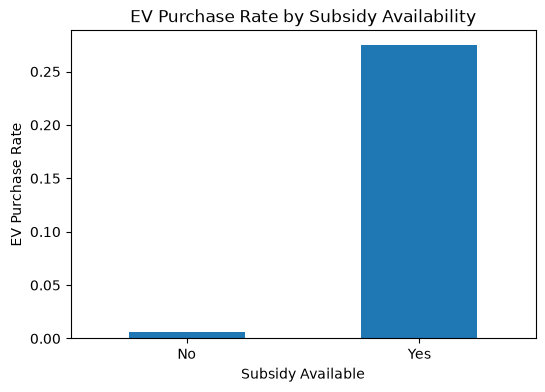

In [57]:
subsidy_rates = (
    analysis_df
    .groupby("Subsidy_Available")["Target"]
    .mean()
)

plt.figure(figsize=(6, 4))
subsidy_rates.plot(kind="bar")

plt.title("EV Purchase Rate by Subsidy Availability")
plt.xlabel("Subsidy Available")
plt.ylabel("EV Purchase Rate")
plt.xticks(rotation=0)

plt.show()

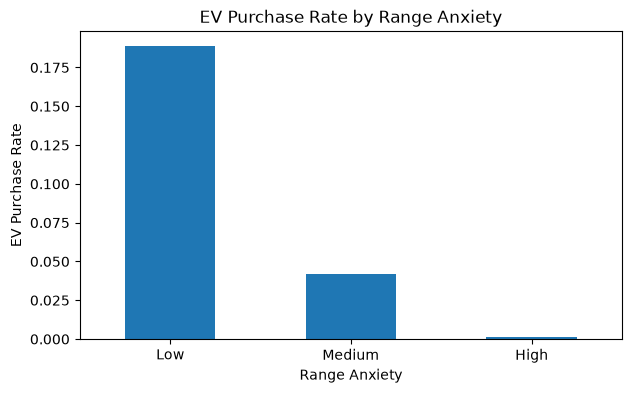

In [58]:
anxiety_rates = (
    analysis_df
    .groupby("Range_Anxiety_Level")["Target"]
    .mean()
    .reindex(["Low", "Medium", "High"])
)

plt.figure(figsize=(7, 4))
anxiety_rates.plot(kind="bar")

plt.title("EV Purchase Rate by Range Anxiety")
plt.xlabel("Range Anxiety")
plt.ylabel("EV Purchase Rate")
plt.xticks(rotation=0)

plt.show()

## Preliminary EDA Findings

- The target is imbalanced, with approximately 17.46% positive observations.
- No missing values or duplicate rows were found.
- Train and test contain the same categorical levels.
- Subsidy availability shows a very strong relationship with EV purchase probability.
- Environmental concern has a strong positive, monotonic relationship with EV purchasing.
- Range anxiety has a strong negative relationship with EV purchasing.
- Annual income shows a strong positive relationship with purchase probability.
- Home charging availability appears moderately predictive.
- Gender, age, and number of cars owned show weak standalone relationships.
- Commute distance shows a weaker nonlinear relationship with purchase probability.
- Charging-station counts show little obvious standalone signal and may interact with other features.
- Further conclusions should be validated through cross-validation rather than relying only on univariate EDA.